# 4. Modeling

This notebook implements the Modeling phase and is directly aligned with the two Business Understanding objectives:
- identify how socioeconomic and demographic factors relate to income level
- provide interpretable insights about variables associated with higher or lower income

Based on Data Understanding, modeling decisions account for:
- target imbalance (`<=50K` majority)
- skewed numeric variables (`capital.gain`, `capital.loss`)
- high-cardinality categories (`native.country`)
- fairness-sensitive differences across `sex` and `race`

Therefore, the modeling workflow includes:
- interpretable baseline (Logistic Regression)
- non-linear benchmarks (Random Forest, SVC)
- validation-based multi-metric comparison
- fairness-aware group evaluation

### 4.0 Reproduce Data Preparation

To keep this notebook reproducible, I rebuild preparation steps here using the same logic as `data-prepration.ipynb`.

Justification linked to Data Understanding:
- Hidden missing values (`?`) were identified in `workclass`, `occupation`, and `native.country`; they are handled as `Unknown` to preserve observations.
- `education` and `education.num` were found to be redundant; dropping `education` avoids duplicated information.
- `native.country` had many rare levels; grouping rare categories (using training frequencies only) reduces sparsity and avoids leakage.
- Numeric skew/outliers were already assessed; robust preprocessing is kept consistent with that decision.

Justification linked to Business Understanding:
- A stable and transparent preprocessing pipeline is necessary so model comparisons are credible and interpretable for final business recommendations.

In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

# Load raw data
df = pd.read_csv(Path("../data/raw/adult.csv"))

# Hidden missing values
for col in ["workclass", "occupation", "native.country"]:
    df[col] = df[col].astype(str).str.strip().replace("?", "Unknown")

# Remove redundant feature
if "education" in df.columns:
    df = df.drop(columns=["education"])

# Split
target_col = "income"
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Rare-category grouping based on training frequencies only
rare_threshold = 0.01
freq = X_train["native.country"].value_counts(normalize=True)
rare_cats = freq[freq < rare_threshold].index.tolist()

def group_rare(series, rare_values, other_label="Other"):
    return series.apply(lambda v: other_label if v in rare_values else v)

for split_df in [X_train, X_val, X_test]:
    split_df["native.country"] = group_rare(split_df["native.country"], rare_cats)

# Preprocessing pipeline
numeric_cols = X_train.select_dtypes(include="number").columns.tolist()
categorical_cols = X_train.select_dtypes(exclude="number").columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]),
        numeric_cols,
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]),
        categorical_cols,
    ),
])

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print("Prepared shapes:")
print("Train:", X_train_proc.shape)
print("Validation:", X_val_proc.shape)
print("Test:", X_test_proc.shape)

Prepared shapes:
Train: (22792, 54)
Validation: (4884, 54)
Test: (4885, 54)


### 4.1 Logistic Regression Baseline

Logistic Regression is the first model because Business Understanding requires interpretable evidence about which factors are associated with high income.

Justification linked to Business Understanding:
- Coefficients provide direct, explainable direction of association (positive/negative) for each feature.
- This supports the objective of reporting actionable insights, not only raw predictive performance.

Justification linked to Data Understanding:
- The target is imbalanced, so `class_weight="balanced"` is used to reduce majority-class dominance.
- One-hot encoding creates many input dimensions; `max_iter=1000` is set to ensure stable convergence.

Evaluation strategy:
- Validation set is used for development; test set remains untouched.
- Precision, Recall, F1, and ROC-AUC are emphasized because Data Understanding showed class imbalance, making accuracy alone insufficient.

In [19]:
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(X_train_proc, y_train)

y_pred_lr = lr.predict(X_val_proc)
y_prob_lr = lr.predict_proba(X_val_proc)[:, 1]

print("Logistic Regression (validation):")
print(classification_report(y_val, y_pred_lr))
print("ROC-AUC:", round(roc_auc_score(y_val, y_prob_lr), 4))

Logistic Regression (validation):
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86      3708
        >50K       0.57      0.84      0.68      1176

    accuracy                           0.81      4884
   macro avg       0.75      0.82      0.77      4884
weighted avg       0.85      0.81      0.82      4884

ROC-AUC: 0.9039


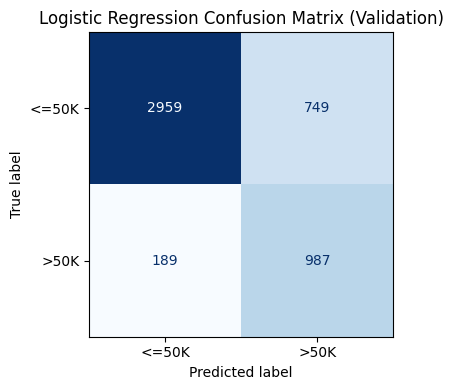

In [20]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_lr, ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Logistic Regression Confusion Matrix (Validation)")
plt.tight_layout()
plt.show()

### 4.2 Random Forest

Random Forest is included as a non-linear benchmark and to complement interpretability from Logistic Regression.

Justification linked to Business Understanding:
- Business objective 1 asks for understanding complex relationships (education, occupation, age, work hours) with income.
- Random Forest can capture non-linear effects and feature interactions that linear models may miss.
- Feature importance supports business objective 2 by highlighting influential variables.

Justification linked to Data Understanding:
- Numeric distributions are skewed, and some variables include extreme values; tree models are robust to these conditions.
- The target is imbalanced; `class_weight="balanced"` is used to improve minority-class sensitivity.
- `n_estimators=200` improves stability of estimates, and `max_depth=20` limits overfitting.

In [21]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_proc, y_train)

y_pred_rf = rf.predict(X_val_proc)
y_prob_rf = rf.predict_proba(X_val_proc)[:, 1]

print("Random Forest (validation):")
print(classification_report(y_val, y_pred_rf))
print("ROC-AUC:", round(roc_auc_score(y_val, y_prob_rf), 4))

Random Forest (validation):
              precision    recall  f1-score   support

       <=50K       0.92      0.85      0.89      3708
        >50K       0.62      0.77      0.69      1176

    accuracy                           0.83      4884
   macro avg       0.77      0.81      0.79      4884
weighted avg       0.85      0.83      0.84      4884

ROC-AUC: 0.9105


### 4.3 Support Vector Classifier (SVC)

SVC is added as a third benchmark to test whether a margin-based non-linear model improves discrimination between income classes.

Justification linked to Business Understanding:
- Comparing multiple model families strengthens confidence in final recommendations.
- If SVC materially improves minority-class detection, it may provide better operational performance even if interpretability is lower.

Justification linked to Data Understanding:
- One-hot encoding produces a high-dimensional feature space, where SVC can perform competitively.
- Target imbalance motivates `class_weight="balanced"`.
- `probability=True` is required so SVC can be compared with LR/RF using ROC-AUC.

Limitation:
- SVC is less directly interpretable, so it is used mainly for predictive benchmarking.

In [22]:
svc = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42,
)
svc.fit(X_train_proc, y_train)

y_pred_svc = svc.predict(X_val_proc)
y_prob_svc = svc.predict_proba(X_val_proc)[:, 1]

print("SVC (validation):")
print(classification_report(y_val, y_pred_svc))
print("ROC-AUC:", round(roc_auc_score(y_val, y_prob_svc), 4))

SVC (validation):
              precision    recall  f1-score   support

       <=50K       0.94      0.79      0.86      3708
        >50K       0.56      0.85      0.68      1176

    accuracy                           0.80      4884
   macro avg       0.75      0.82      0.77      4884
weighted avg       0.85      0.80      0.82      4884

ROC-AUC: 0.9011


### 4.4 Model Comparison

I compare models using multiple metrics rather than accuracy only.

Justification linked to Business Understanding:
- The project needs both predictive reliability and meaningful insights; therefore model selection cannot rely on one metric.
- A better model is one that balances useful detection of `>50K` cases with acceptable false positives.

Justification linked to Data Understanding:
- Because the target is imbalanced, accuracy is potentially misleading.
- Precision, Recall, and F1 are necessary to evaluate minority-class behavior.
- ROC-AUC adds threshold-independent comparison of ranking quality.

Methodological justification:
- All models use the same validation split and preprocessing pipeline for fair comparison.
- The test set is held back to avoid optimistic bias during model choice.

,Precision,Recall,F1,ROC-AUC
Model,,,,
Logistic Regression,0.5685,0.8393,0.6779,0.9039
Random Forest,0.6243,0.7730,0.6907,0.9105
SVC,0.5620,0.8478,0.6759,0.9011


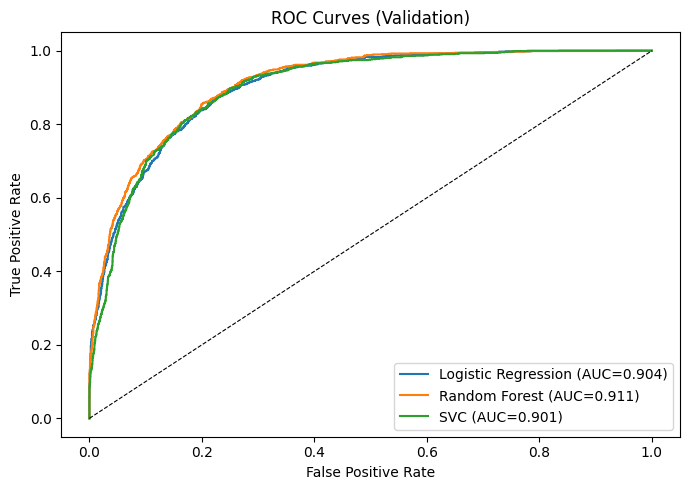

In [23]:
pos_label = ">50K"

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVC"],
    "Precision": [
        precision_score(y_val, y_pred_lr, pos_label=pos_label),
        precision_score(y_val, y_pred_rf, pos_label=pos_label),
        precision_score(y_val, y_pred_svc, pos_label=pos_label),
    ],
    "Recall": [
        recall_score(y_val, y_pred_lr, pos_label=pos_label),
        recall_score(y_val, y_pred_rf, pos_label=pos_label),
        recall_score(y_val, y_pred_svc, pos_label=pos_label),
    ],
    "F1": [
        f1_score(y_val, y_pred_lr, pos_label=pos_label),
        f1_score(y_val, y_pred_rf, pos_label=pos_label),
        f1_score(y_val, y_pred_svc, pos_label=pos_label),
    ],
    "ROC-AUC": [
        roc_auc_score(y_val, y_prob_lr),
        roc_auc_score(y_val, y_prob_rf),
        roc_auc_score(y_val, y_prob_svc),
    ],
}).set_index("Model").round(4)

display(comparison)

fpr_lr, tpr_lr, _ = roc_curve(y_val, y_prob_lr, pos_label=pos_label)
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_prob_rf, pos_label=pos_label)
fpr_svc, tpr_svc, _ = roc_curve(y_val, y_prob_svc, pos_label=pos_label)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_score(y_val, y_prob_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_val, y_prob_rf):.3f})")
plt.plot(fpr_svc, tpr_svc, label=f"SVC (AUC={roc_auc_score(y_val, y_prob_svc):.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=0.8)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Validation)")
plt.legend()
plt.tight_layout()
plt.show()

### 4.5 Interpretability

This section translates model outputs into business-facing findings.

Justification linked to Business Understanding:
- Objective 2 requires interpretable evidence of which variables are associated with higher/lower income.
- Logistic Regression coefficients provide signed direction of association.
- Random Forest importance highlights variables with high predictive contribution.

Justification linked to Data Understanding:
- Earlier analysis showed strong differences across education, occupation, age, and hours worked.
- This section verifies whether those patterns remain influential in predictive models.

Note:
- SVC is retained for predictive comparison but not used as the primary explanation model due to lower transparency.

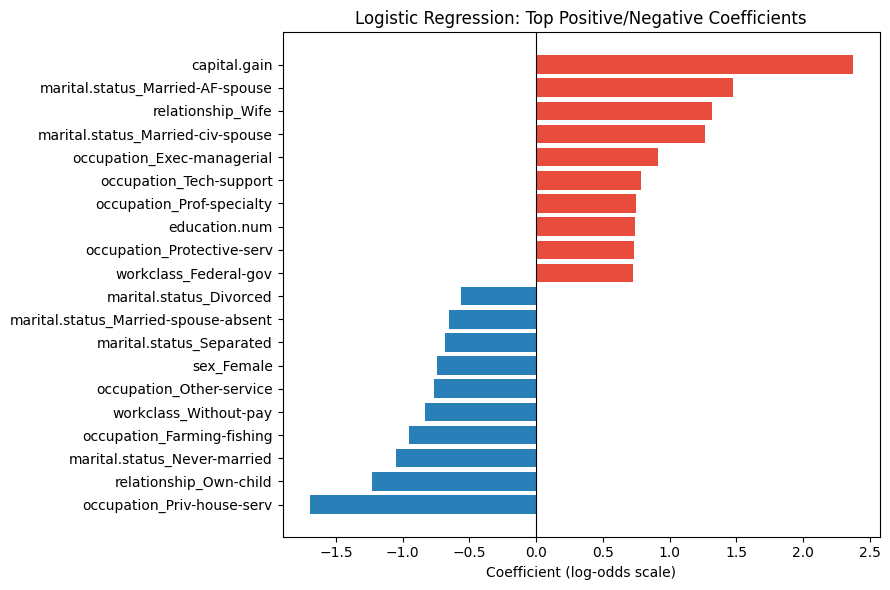

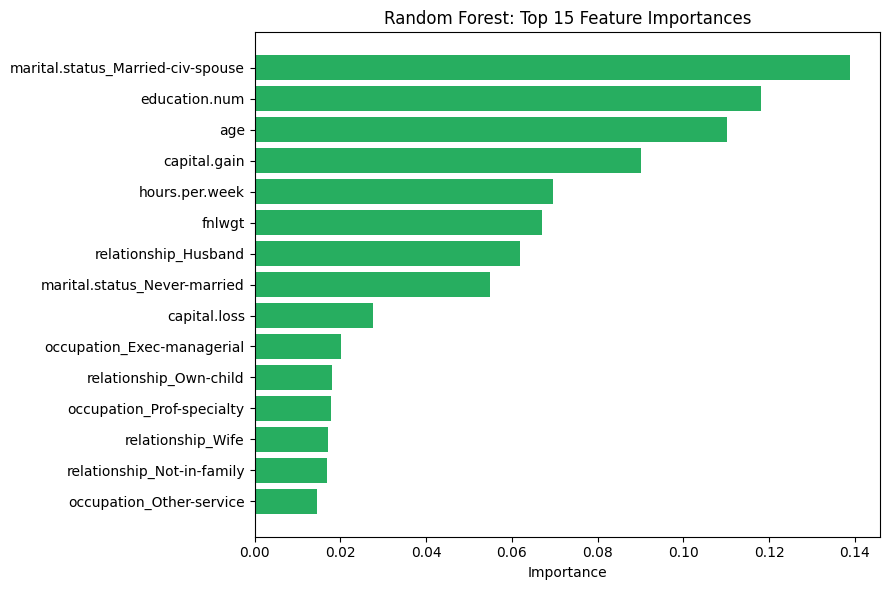

In [24]:
ohe_names = preprocessor.named_transformers_["cat"]["encoder"].get_feature_names_out(categorical_cols)
feature_names = numeric_cols + list(ohe_names)

# Logistic Regression coefficients
coef_series = pd.Series(lr.coef_[0], index=feature_names)
coef_top = pd.concat([coef_series.nlargest(10), coef_series.nsmallest(10)]).sort_values()

plt.figure(figsize=(9, 6))
colors = ["#E74C3C" if v > 0 else "#2980B9" for v in coef_top.values]
plt.barh(coef_top.index, coef_top.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression: Top Positive/Negative Coefficients")
plt.xlabel("Coefficient (log-odds scale)")
plt.tight_layout()
plt.show()

# Random Forest importance
rf_imp = pd.Series(rf.feature_importances_, index=feature_names).nlargest(15).sort_values()
plt.figure(figsize=(9, 6))
plt.barh(rf_imp.index, rf_imp.values, color="#27AE60")
plt.title("Random Forest: Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### 4.6 Fairness-Aware Evaluation

Fairness-aware evaluation is required because Data Understanding showed unequal income distribution and potentially different risk profiles across `sex` and `race` groups.

Justification linked to Business Understanding:
- The project should provide responsible, trustworthy insights; high overall accuracy is not enough if one group is systematically disadvantaged.
- Group-level performance helps assess whether model recommendations are robust for different subpopulations.

Justification linked to Data Understanding:
- Group differences observed during EDA motivate per-group diagnostics.
- Group-wise Precision and Recall measure quality consistency.
- Group-wise FNR is critical: high FNR means true `>50K` cases are being missed disproportionately in a group.

Methodological note:
- Metrics are computed on the same validation split for all three models to support consistent fairness comparison before final test evaluation.

In [17]:
def group_metrics(y_true, y_pred, x_df, group_col, pos_label=">50K"):
    rows = []
    y_pred_s = pd.Series(y_pred, index=y_true.index)
    for group in sorted(x_df[group_col].dropna().unique()):
        mask = x_df[group_col] == group
        yt = y_true[mask]
        yp = y_pred_s[mask]
        if yt.nunique() < 2:
            continue
        p = precision_score(yt, yp, pos_label=pos_label, zero_division=0)
        r = recall_score(yt, yp, pos_label=pos_label, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=["<=50K", ">50K"]).ravel()
        fnr = fn / (fn + tp) if (fn + tp) else 0
        rows.append({"Group": group, "Precision": p, "Recall": r, "FNR": fnr, "Count": int(mask.sum())})
    return pd.DataFrame(rows).set_index("Group").round(3)

print("Logistic Regression - by sex")
display(group_metrics(y_val, y_pred_lr, X_val, "sex"))
print("Logistic Regression - by race")
display(group_metrics(y_val, y_pred_lr, X_val, "race"))

print("Random Forest - by sex")
display(group_metrics(y_val, y_pred_rf, X_val, "sex"))
print("Random Forest - by race")
display(group_metrics(y_val, y_pred_rf, X_val, "race"))

print("SVC - by sex")
display(group_metrics(y_val, y_pred_svc, X_val, "sex"))
print("SVC - by race")
display(group_metrics(y_val, y_pred_svc, X_val, "race"))

Logistic Regression - by sex


,Precision,Recall,FNR,Count
Group,,,,
Female,0.590,0.753,0.247,1586
Male,0.566,0.854,0.146,3298


Logistic Regression - by race


,Precision,Recall,FNR,Count
Group,,,,
Amer-Indian-Eskimo,0.333,0.600,0.400,43
Asian-Pac-Islander,0.510,0.743,0.257,154
Black,0.542,0.709,0.291,436
Other,0.200,1.000,0.000,43
White,0.574,0.850,0.150,4208


Random Forest - by sex


...

,Precision,Recall,FNR,Count
Group,,,,
Amer-Indian-Eskimo,0.600,0.600,0.400,43
Asian-Pac-Islander,0.639,0.657,0.343,154
Black,0.636,0.636,0.364,436
Other,0.333,1.000,0.000,43
White,0.624,0.784,0.216,4208


SVC - by sex


,Precision,Recall,FNR,Count
Group,,,,
Female,0.577,0.771,0.229,1586
Male,0.560,0.861,0.139,3298


SVC - by race


,Precision,Recall,FNR,Count
Group,,,,
Amer-Indian-Eskimo,0.375,0.600,0.400,43
Asian-Pac-Islander,0.519,0.771,0.229,154
Black,0.548,0.836,0.164,436
Other,0.200,1.000,0.000,43
White,0.566,0.852,0.148,4208
